<a href="https://colab.research.google.com/github/parasssssss/trader-sentiment-analysis/blob/main/notebook/Primetrade_ai_round_0_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A — Data preparation (must-have)

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

trades = pd.read_csv("/content/historical_data - historical_data.csv")
sentiment = pd.read_csv("/content/fear_greed_index - fear_greed_index.csv")

print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

print("\nTrades columns:\n", trades.columns)
print("\nSentiment columns:\n", sentiment.columns)

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)

Trades columns:
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Sentiment columns:
 Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


- Trades dataset has 211224 rows and 16 columns
- Sentiment dataset has 2644 rows and 4 columns

***This block checks for missing data in both datasets (`trades` and `sentiment`).***

In [6]:
print("\nMissing values in trades:\n", trades.isnull().sum())
print("\nMissing values in sentiment:\n", sentiment.isnull().sum())


Missing values in trades:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values in sentiment:
 timestamp         0
value             0
classification    0
date              0
dtype: int64


- Trades dataset has no NULL values
- Sentiment dataset has no NULL values

***This block checks for duplicate rows in both datasets (`trades` and `sentiment`).***

In [7]:
print("Duplicate rows in trades:", trades.duplicated().sum())
print("Duplicate rows in sentiment:", sentiment.duplicated().sum())

Duplicate rows in trades: 0
Duplicate rows in sentiment: 0


- Trades dataset has no DUPLICATE values
- Sentiment dataset has no DUPLICATE values

# Convert into DATETIME

This block standardizes the date columns in both DataFrames for consistent analysis.

In [8]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# Key Metrics
***This block calculates key daily trading metrics (PnL, trade count, average size, win rate, long/short ratio) and merges them with sentiment data.***

In [9]:
daily_pnl = trades.groupby(['Account','date'])['Closed PnL'].sum().reset_index()
trade_count = trades.groupby(['Account','date']).size().reset_index(name='trades')
avg_size = trades.groupby(['Account','date'])['Size USD'].mean().reset_index(name='avg_size')
trades['win'] = trades['Closed PnL'] > 0
win_rate = trades.groupby(['Account','date'])['win'].mean().reset_index(name='win_rate')
long_trades = trades[trades['Side'] == 'BUY'].groupby(['Account','date']).size()
short_trades = trades[trades['Side'] == 'SELL'].groupby(['Account','date']).size()
ratio = (long_trades / short_trades).reset_index(name='long_short_ratio')
df = daily_pnl.merge(trade_count, on=['Account','date'])
df = df.merge(avg_size, on=['Account','date'])
df = df.merge(win_rate, on=['Account','date'])
df = df.merge(ratio, on=['Account','date'], how='left')
final_df = df.merge(sentiment[['date','classification']], on='date', how='left')

### Data Preparation Summary

- Converted timestamps to daily level
- Created key metrics:
  - Daily PnL
  - Trade frequency
  - Average trade size
  - Win rate
  - Long/Short ratio
- Merged trader data with market sentiment dataset

#Part B — Analysis (must-have)

***This section analyzes the relationship between market sentiment and trader performance metrics like PnL and win rate.***


# PnL & win_rate based on classification



***Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?***


In [10]:
perf = final_df.groupby('classification').agg({
    'Closed PnL': 'mean',
    'win_rate': 'mean'
}).reset_index()

print(perf)

  classification   Closed PnL  win_rate
0   Extreme Fear  4619.439053  0.329659
1  Extreme Greed  5161.922644  0.386387
2           Fear  5328.818161  0.364033
3          Greed  3318.100730  0.343559
4        Neutral  3438.618818  0.355414


# Insights
- **Extreme Greed:** Traders see their best profits and win rates here. Strong bullish markets make for easy wins.
- **Fear:** Surprisingly, profits are also high during fear! Smart traders can turn market panic into gains.
- **Win Rates:** Highest when everyone is greedy, and lower when fear grips the market. Stable markets are easier to win in.

***Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?***


***This section examines how trader behavior, including trade frequency, average trade size, and long/short ratio, changes with market sentiment.***

# Trades, avg_size & long_short_ratio based on classification

In [11]:
behavior = final_df.groupby('classification').agg({
    'trades': 'mean',
    'avg_size': 'mean',
    'long_short_ratio': 'mean'
}).reset_index()

print(behavior)

  classification      trades     avg_size  long_short_ratio
0   Extreme Fear  133.750000  6773.464125          3.268598
1  Extreme Greed   76.030418  5371.637182          1.903983
2           Fear   98.153968  8975.928546          2.831197
3          Greed   77.628086  6427.866594          2.513434
4        Neutral  100.228723  6963.694861          3.027277


### Insight 1: Higher Trading Activity During Fear
Traders execute the highest number of trades during Extreme Fear periods, indicating that market panic or volatility leads to increased trading activity.

### Insight 2: Larger Trade Sizes in Fear Markets
Average trade size is highest during Fear conditions, suggesting that traders take bigger positions to capitalize on uncertain and volatile price movements.

### Insight 3: Strong Long Bias During Fear
The long/short ratio peaks during Extreme Fear, showing that traders prefer taking long positions even in bearish conditions, possibly expecting price reversals.

### Insight 4: Lower Activity in Greed Periods
Trading frequency and position sizes are relatively lower during Greed periods, indicating more stable and less aggressive trading behavior.

***This block categorizes traders into 'High' or 'Low' frequency based on their daily trade count.***

In [12]:
final_df['trader_type'] = final_df['trades'].apply(
    lambda x: 'High' if x > final_df['trades'].median() else 'Low'
)

***This block compares the average PnL of high-frequency versus low-frequency traders across different market sentiments.***

In [13]:
seg1 = final_df.groupby(['classification','trader_type'])['Closed PnL'].mean().reset_index()
print(seg1)

  classification trader_type    Closed PnL
0   Extreme Fear        High   6799.753651
1   Extreme Fear         Low    457.020275
2  Extreme Greed        High   8437.437459
3  Extreme Greed         Low   1627.473851
4           Fear        High  10311.492505
5           Fear         Low    913.034911
6          Greed        High   5486.377107
7          Greed         Low   1401.949513
8        Neutral        High   5759.162182
9        Neutral         Low   1118.075454


### Insight: Active Traders Benefit More from Market Volatility

- High-frequency traders outperform low-frequency traders in every sentiment category, with the highest gains observed during Fear and Extreme Greed periods.

- This indicates that frequent trading allows better capture of short-term opportunities, especially in volatile or high-momentum markets, while less active traders miss out on these opportunities.

***This block classifies each daily trading record as either a 'Winner' or a 'Loser' based on the 'Closed PnL'.***

In [14]:
final_df['performance_type'] = final_df['Closed PnL'].apply(
    lambda x: 'Winner' if x > 0 else 'Loser'
)

***This block categorizes trades as 'Large' or 'Small' based on their average size to analyze the impact of position sizing.***

In [15]:
final_df['size_type'] = final_df['avg_size'].apply(
    lambda x: 'Large' if x > final_df['avg_size'].median() else 'Small'
)

***This block handles any missing values in the `long_short_ratio` column by filling them with zero.***

In [16]:
final_df['long_short_ratio'] = final_df['long_short_ratio'].fillna(0)

***This block displays the first few rows of the final DataFrame (`final_df`) to review the processed data.***

In [17]:
print(final_df.head())

                                      Account        date  Closed PnL  trades  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11         0.0     177   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17         0.0      68   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18         0.0      40   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22    -21227.0      12   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26      1603.1      27   

       avg_size  win_rate  long_short_ratio classification trader_type  \
0   5089.718249  0.000000               0.0  Extreme Greed        High   
1   7976.664412  0.000000               0.0  Extreme Greed        High   
2  23734.500000  0.000000               0.0  Extreme Greed        High   
3  28186.666667  0.000000               0.0  Extreme Greed         Low   
4  17248.148148  0.444444               0.8  Extreme Greed         Low   

  performance_type size_type  
0            Loser     Large  
1     

***This block calculates and displays the mean PnL and win rate, grouped by market sentiment, to identify the most profitable conditions.***

In [18]:
print(final_df.groupby('classification')[['Closed PnL','win_rate']].mean().sort_values(by='Closed PnL', ascending=False))

                 Closed PnL  win_rate
classification                       
Fear            5328.818161  0.364033
Extreme Greed   5161.922644  0.386387
Extreme Fear    4619.439053  0.329659
Neutral         3438.618818  0.355414
Greed           3318.100730  0.343559


### Insight 1: Highest Profitability During Fear Markets
Traders achieve the highest average PnL during Fear periods, indicating that volatile and uncertain market conditions provide strong profit opportunities for active traders.

### Insight 2: Strong Performance in Extreme Greed
Extreme Greed also shows high PnL along with the highest win rate, suggesting that strong bullish momentum leads to more consistent and profitable trades.

### Insight 3: Lower Profitability in Greed and Neutral Markets
Greed and Neutral conditions show relatively lower PnL, indicating that moderate or stable market sentiment offers fewer trading opportunities compared to extreme conditions.

### Insight 4: Win Rate Peaks in Extreme Greed
Win rate is highest during Extreme Greed, showing that traders are more consistently successful when the market trend is strongly positive.

***This block displays the mean trade counts, average trade sizes, and long/short ratios grouped by market sentiment, revealing behavioral patterns.***

In [19]:
print(final_df.groupby('classification')[['trades','avg_size','long_short_ratio']].mean())

                    trades     avg_size  long_short_ratio
classification                                           
Extreme Fear    133.750000  6773.464125          2.185875
Extreme Greed    76.030418  5371.637182          1.201754
Fear             98.153968  8975.928546          1.626815
Greed            77.628086  6427.866594          1.442897
Neutral         100.228723  6963.694861          1.900099


### Insight 1: Highest Trading Activity in Extreme Fear
Traders execute the most trades during Extreme Fear periods, indicating that high volatility and panic drive increased market participation.

### Insight 2: Larger Positions Taken During Fear
Average trade size is highest during Fear conditions, suggesting that traders take bigger positions to capitalize on uncertain and volatile price movements.

### Insight 3: Reduced Activity in Greed Markets
Trading frequency and position sizes are lower during Greed and Extreme Greed periods, indicating more stable and less aggressive trading behavior.

### Insight 4: Long Bias Across All Conditions
The long/short ratio remains above 1 in all sentiment categories, showing a consistent preference for long positions, though it is strongest during Extreme Fear.

#Identify 2–3 segments

***This block shows the average PnL for high-frequency vs. low-frequency traders across different market sentiment classifications.***

trader_type             High          Low
classification                           
Extreme Fear     6799.753651   457.020275
Extreme Greed    8437.437459  1627.473851
Fear            10311.492505   913.034911
Greed            5486.377107  1401.949513
Neutral          5759.162182  1118.075454


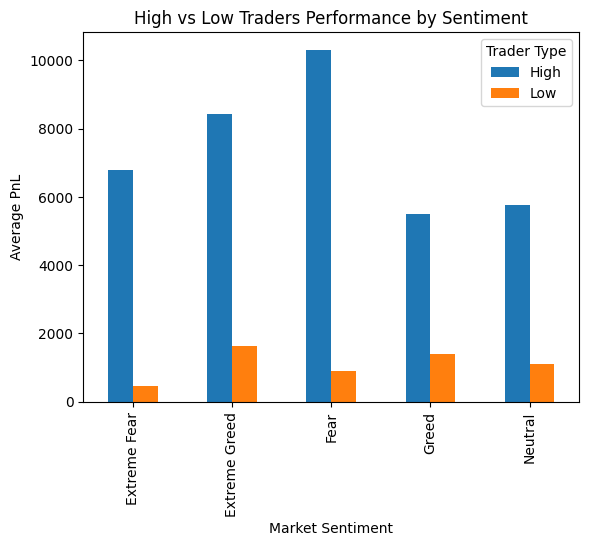

In [52]:

trader_perf = final_df.groupby(['classification','trader_type'])['Closed PnL'].mean().unstack()
print(trader_perf)


trader_perf.plot(kind='bar')
plt.title("High vs Low Traders Performance by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")
plt.legend(title="Trader Type")
plt.show()

### Insight 1: High-Frequency Traders Consistently Outperform
High-frequency traders generate significantly higher average PnL compared to low-frequency traders across all market conditions.

### Insight 2: Maximum Advantage During Fear Markets
The performance gap is largest during Fear periods, where high-frequency traders earn substantially higher profits, indicating their ability to capitalize on volatility.

### Insight 3: Strong Gains in Extreme Greed for Active Traders
High-frequency traders also achieve very high profits during Extreme Greed, showing that active trading benefits from strong market trends.

### Insight 4: Low-Frequency Traders Show Limited Profitability
Low-frequency traders consistently earn much lower PnL across all sentiments, suggesting missed opportunities and less effective trading strategies.

***This block compares the average PnL of winning trades versus losing trades, segmented by market sentiment, to understand risk-reward dynamics.***

performance_type        Loser        Winner
classification                             
Extreme Fear     -7524.650313  12715.498631
Extreme Greed    -1353.654330   8192.845637
Fear             -1560.513241   9831.294590
Greed            -3417.662797   7604.495702
Neutral          -2034.764124   6760.073424


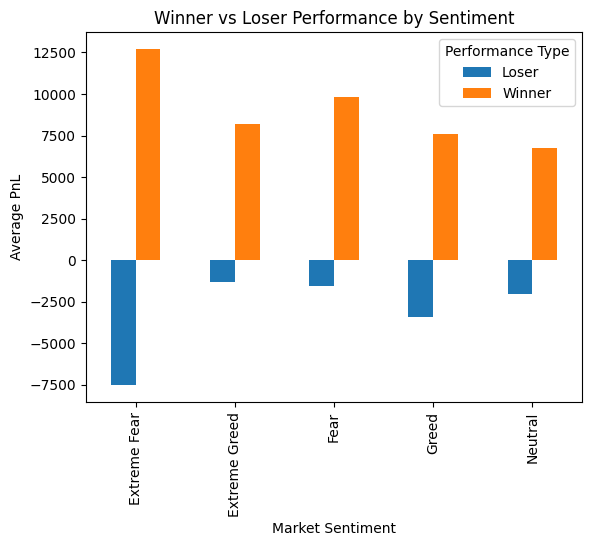

In [53]:

perf_type = final_df.groupby(['classification','performance_type'])['Closed PnL'].mean().unstack()
print(perf_type)

perf_type.plot(kind='bar')
plt.title("Winner vs Loser Performance by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")
plt.legend(title="Performance Type")
plt.show()

### Insight 1: Winners Generate Strong Profits Across All Market Conditions
Winning trades consistently produce high positive PnL across all sentiment categories, with the highest gains observed during Extreme Fear and Fear periods.

### Insight 2: Losses Are Highest During Extreme Fear
Losing trades show the largest negative PnL during Extreme Fear, indicating that volatile and uncertain markets increase downside risk.

### Insight 3: Favorable Risk-Reward in Fear Markets
Despite higher losses, Fear conditions also deliver the highest winning PnL, suggesting a high risk–high reward environment for traders.

### Insight 4: More Stable Outcomes in Greed Markets
Greed and Neutral conditions show relatively smaller losses and steady profits, indicating more stable but less extreme trading outcomes.

***This block analyzes the impact of position size by comparing the average PnL of 'Large' versus 'Small' trades across various market sentiments.***

size_type             Large        Small
classification                          
Extreme Fear    8445.038316    60.163219
Extreme Greed   6505.194438  3734.367129
Fear            9871.490346  1172.756375
Greed           4312.582036  2260.276665
Neutral         6403.719647   829.330088


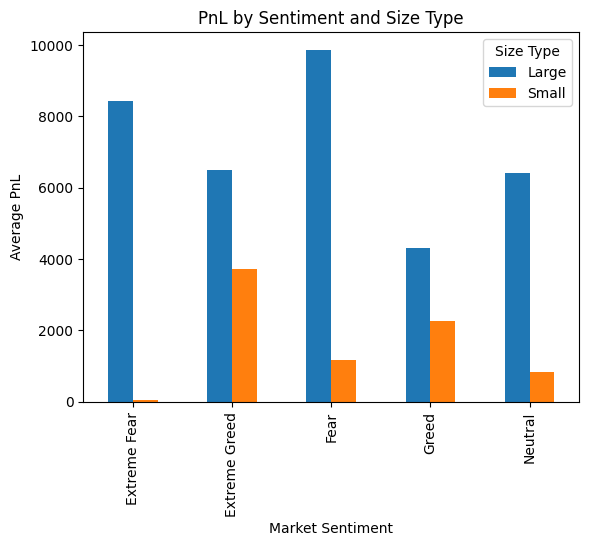

In [49]:

size_perf = final_df.groupby(['classification','size_type'])['Closed PnL'].mean().unstack()
print(size_perf)
size_perf.plot(kind='bar')
plt.title("PnL by Sentiment and Size Type")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")
plt.legend(title="Size Type")
plt.show()

### Insight: Large Trades Drive Higher Profitability

Large trades consistently generate significantly higher PnL compared to small trades across all market conditions.

The difference is especially prominent during Fear periods, indicating that bigger positions help capture higher returns in volatile markets.

Small trades show relatively low profitability, suggesting limited upside with conservative position sizing.

***This block generates a bar chart to visually represent the average PnL across different market sentiment categories.***

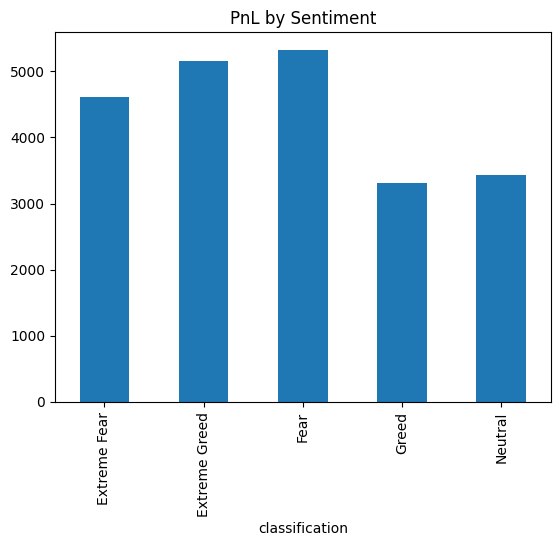

In [25]:
final_df.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title("PnL by Sentiment")
plt.show()

### Insight: Higher Profitability in Fear and Extreme Greed Conditions

- The chart shows that average PnL is highest during Fear and Extreme Greed periods, indicating that traders benefit most during highly volatile or strongly trending market conditions.

- In contrast, Greed and Neutral periods exhibit significantly lower PnL, suggesting fewer profitable opportunities when market sentiment is moderate or stable.

- This highlights that extreme market emotions (both fear and optimism) create better trading opportunities compared to balanced market conditions.

***This block generates a bar chart illustrating the average number of trades conducted during each market sentiment.***

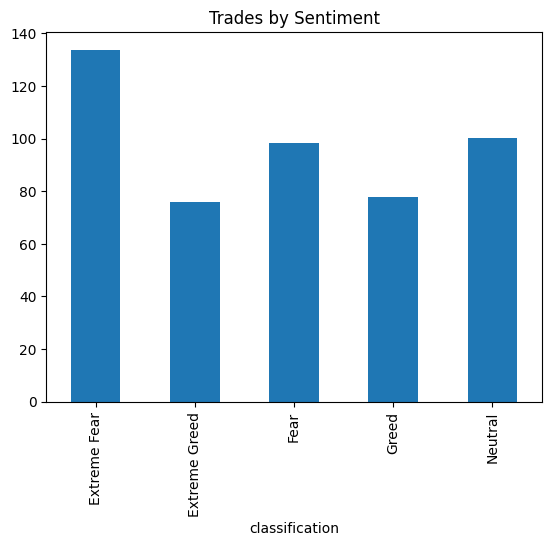

In [26]:
final_df.groupby('classification')['trades'].mean().plot(kind='bar')
plt.title("Trades by Sentiment")
plt.show()

### Insight: Increased Trading Activity During Extreme Fear

- The chart shows that the number of trades is highest during Extreme Fear periods, indicating that traders become more active when the market is highly volatile or uncertain.

- Trading activity is comparatively lower during Greed and Extreme Greed conditions, suggesting that traders are less aggressive when the market is stable or trending positively.

- This pattern highlights that fear-driven markets lead to increased participation, likely due to panic trading or attempts to capitalize on rapid price movements.

#Risk-Taking vs Conservative Traders

In [38]:
final_df['risk_type'] = final_df.apply(
    lambda x: 'High Risk' if (x['avg_size'] > final_df['avg_size'].median() and x['trades'] > final_df['trades'].median())
    else 'Low Risk', axis=1
)

risk_type          High Risk     Low Risk
classification                           
Extreme Fear    12076.880029   263.112146
Extreme Greed   11206.128005  3297.540891
Fear            20111.834322  1297.086481
Greed            8109.731336  2184.203411
Neutral         11735.696978  1231.651900


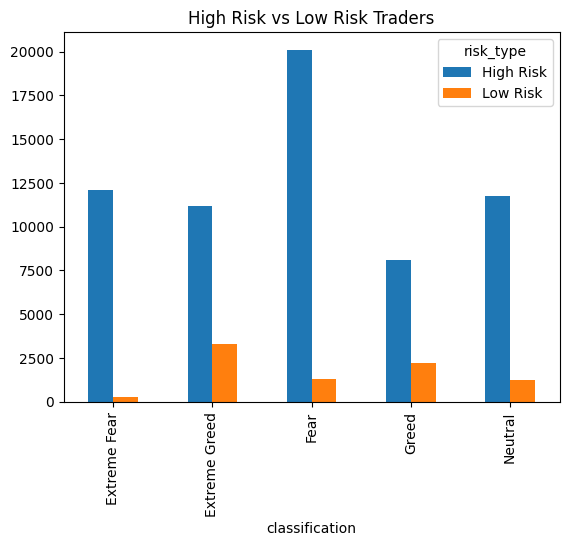

In [44]:
print(final_df.groupby(['classification','risk_type'])['Closed PnL'].mean().unstack())

final_df.groupby(['classification','risk_type'])['Closed PnL'].mean().unstack().plot(kind='bar')
plt.title("High Risk vs Low Risk Traders")
plt.show()

### Insight: High-Risk Traders Generate Significantly Higher Profits

High-risk traders consistently achieve much higher PnL compared to low-risk traders across all market conditions.

The difference is especially large during Fear periods, indicating that taking larger positions with higher activity leads to greater profit opportunities in volatile markets.

However, this also suggests higher exposure to risk, highlighting a strong risk–reward trade-off.

#Long-Biased vs Balanced Traders

In [35]:
final_df['bias_type'] = final_df['long_short_ratio'].apply(
    lambda x: 'Long-Biased' if x > 1.5 else 'Balanced'
)

bias_type          Balanced  Long-Biased
classification                          
Extreme Fear    5785.123363  -646.238348
Extreme Greed   5757.545186  2071.692750
Fear            4672.406188  7605.310751
Greed           4153.915524 -1316.872220
Neutral         3901.786519  1945.033084


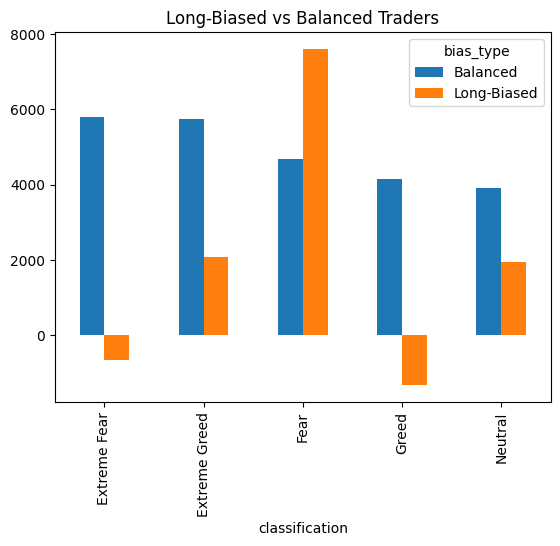

In [45]:
print(final_df.groupby(['classification','bias_type'])['Closed PnL'].mean().unstack())
final_df.groupby(['classification','bias_type'])['Closed PnL'].mean().unstack().plot(kind='bar')
plt.title("Long-Biased vs Balanced Traders")
plt.show()

### Insight: Mixed Performance for Long-Biased Traders

Long-biased traders outperform during Fear periods, suggesting they benefit from market rebounds in volatile conditions.

However, they underperform in Extreme Fear and Greed periods, indicating that relying heavily on long positions can be risky in uncertain or moderately bullish markets.

Balanced traders show more stable performance across all sentiments, highlighting the advantage of diversified trading strategies.

#Consistent vs Inconsistent Traders

In [36]:
final_df['consistency'] = final_df['win_rate'].apply(
    lambda x: 'Consistent' if x > 0.5 else 'Inconsistent'
)

consistency       Consistent  Inconsistent
classification                            
Extreme Fear    14766.469130   1348.908698
Extreme Greed   14159.989482    976.192387
Fear            13041.794335   1499.810987
Greed            9236.692675    899.197935
Neutral          9976.888160    593.722997


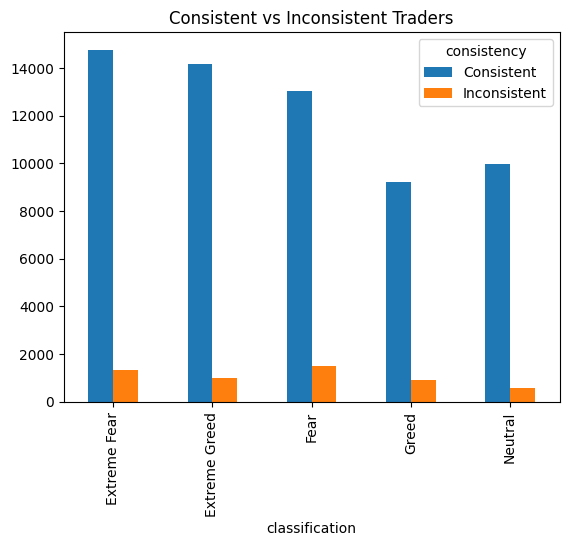

In [46]:
print(final_df.groupby(['classification','consistency'])['Closed PnL'].mean().unstack())
final_df.groupby(['classification','consistency'])['Closed PnL'].mean().unstack().plot(kind='bar')
plt.title("Consistent vs Inconsistent Traders")
plt.show()

### Insight: Consistent Traders Strongly Outperform

Consistent traders (higher win rate) generate significantly higher PnL compared to inconsistent traders across all market conditions.

The performance gap is especially large in Extreme Fear and Extreme Greed, indicating that disciplined trading leads to better outcomes in volatile markets.

Inconsistent traders show very low profitability, highlighting the importance of maintaining a stable and reliable trading strategy.

#Part C — “Actionable output”

### Strategy 1: Increase Trading Activity During High Volatility (Fear & Extreme Greed)

Based on the analysis, both Fear and Extreme Greed periods show higher average PnL, indicating strong trading opportunities during volatile or highly trending markets.

- Traders should increase trading frequency during these conditions.
- High-frequency traders particularly benefit the most, as they can capture short-term price movements effectively.
- However, risk management is crucial due to higher downside potential in Fear markets.

---

### Strategy 2: Use Larger Position Sizes Selectively in Fear Markets

Large trades consistently generate higher profits, especially during Fear and Extreme Fear periods where volatility is high.

- Traders can consider increasing position sizes during Fear conditions to maximize returns.
- This strategy should be applied cautiously, as losses are also higher in these periods (high risk–high reward).
- Position sizing should be combined with strict stop-loss mechanisms.

---

### Strategy 3: Avoid Overtrading in Stable (Greed & Neutral) Markets

Greed and Neutral periods show lower PnL and reduced trading effectiveness.

- Traders should reduce trading frequency during these conditions.
- Focus should be on high-confidence trades rather than frequent entries.
- Low-frequency or swing trading strategies may perform better in stable market environments.

---

### Strategy 4: Favor Active Trading Strategies Over Passive Ones

High-frequency traders consistently outperform low-frequency traders across all sentiment conditions.

- Active trading strategies should be preferred, especially during volatile markets.
- Traders should adapt dynamically to market sentiment rather than maintaining a fixed trading approach.

##Bonus
***This section prepares to identify distinct trader archetypes by aggregating key performance metrics for each individual account.***

In [28]:
trader_features = final_df.groupby('Account').agg({
    'Closed PnL': 'mean',
    'trades': 'mean',
    'avg_size': 'mean',
    'win_rate': 'mean'
}).reset_index()


***This block applies K-Means clustering to group traders with similar characteristics (PnL, trades, size, win rate) and displays the mean metrics for each cluster.***

In [31]:
from sklearn.cluster import KMeans

X = trader_features[['Closed PnL','trades','avg_size','win_rate']]

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(X)
print(trader_features.groupby('cluster').mean(numeric_only=True))

           Closed PnL      trades      avg_size  win_rate
cluster                                                  
0        10942.426620  168.467043  16773.335828  0.345741
1         2501.155871   83.750053   3850.008958  0.354709
2        66676.242499  159.083333  33569.102224  0.352333


***This block visualizes the identified trader clusters on a scatter plot, showing the relationship between trades, PnL, and cluster assignment.***

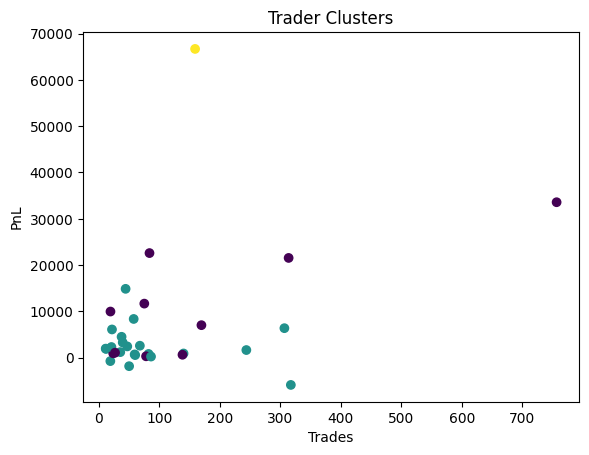

In [33]:
plt.scatter(trader_features['trades'], trader_features['Closed PnL'], c=trader_features['cluster'])
plt.xlabel("Trades")
plt.ylabel("PnL")
plt.title("Trader Clusters")
plt.show()

### Trader Segmentation Using Clustering

Traders were grouped into 3 distinct clusters based on their trading behavior and performance metrics.

### Cluster 0: Active High-Volume Traders
- High number of trades (~168 trades)
- Large average position size
- Strong profitability

These traders are highly active and take relatively large positions, leading to strong overall performance.

---

### Cluster 1: Moderate / Conservative Traders
- Moderate trading activity (~84 trades)
- Smaller trade sizes
- Lower profitability

These traders follow a more conservative approach with limited risk exposure, resulting in lower returns.

---

### Cluster 2: Aggressive High-Value Traders (Top Performers)
- Very high PnL (~66,676)
- Large trade sizes
- High trading activity

This group represents the most aggressive and high-performing traders, combining large position sizes with active trading strategies to achieve exceptional profits.

---

### Key Takeaway
Clustering reveals that higher profitability is strongly associated with:
- Increased trading activity
- Larger position sizes

This highlights the importance of aggressive but strategic trading behavior in maximizing returns.